# Power Consumption Analysis

## Project overview

This project analyzes electricity consumption across three distribution
zones in Tetouan, Morocco.

The objective is to identify daily, monthly, and hourly consumption
patterns, compare the three zones, examine differences between weekdays
and weekends, and explore the relationship between temperature and
electricity consumption.

## 1. Dataset

The dataset contains electricity consumption data for three urban zones,
as well as weather-related variables such as temperature, humidity,
wind speed, general diffuse flows, and diffuse flows.

The observations were recorded every 10 minutes during 2017.

In [118]:
import pandas as pd

cons = pd.read_csv("data/powerconsumption.csv",
                parse_dates= ["Datetime"])

## 2. Data inspection

The dataset was inspected to understand its size, column types, missing
values, and duplicate records.

In [50]:
cons.shape

(52416, 9)

In [51]:
cons.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Datetime                52416 non-null  datetime64[ns]
 1   Temperature             52416 non-null  float64       
 2   Humidity                52416 non-null  float64       
 3   WindSpeed               52416 non-null  float64       
 4   GeneralDiffuseFlows     52416 non-null  float64       
 5   DiffuseFlows            52416 non-null  float64       
 6   PowerConsumption_Zone1  52416 non-null  float64       
 7   PowerConsumption_Zone2  52416 non-null  float64       
 8   PowerConsumption_Zone3  52416 non-null  float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 3.6 MB


In [52]:
cons.isna().sum()

Datetime                  0
Temperature               0
Humidity                  0
WindSpeed                 0
GeneralDiffuseFlows       0
DiffuseFlows              0
PowerConsumption_Zone1    0
PowerConsumption_Zone2    0
PowerConsumption_Zone3    0
dtype: int64

In [53]:
cons.duplicated().sum()

np.int64(0)

## 3. Data preparation

New time-based features were created from the Datetime column. Total
electricity consumption was calculated as the sum of consumption across
the three zones.

The original 10-minute observations were also resampled into hourly
averages for further analysis.

In [54]:
cons["total_consumption"]=cons["PowerConsumption_Zone1"]+cons["PowerConsumption_Zone2"]+cons["PowerConsumption_Zone3"]
cons["hour"] = cons["Datetime"].dt.hour
cons["day_of_week"] = cons["Datetime"].dt.dayofweek
cons["month"] = cons["Datetime"].dt.month
cons["month_name"] = cons["Datetime"].dt.month_name()

In [55]:
day_of_week = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
cons["day_name"] = pd.Categorical(cons["Datetime"].dt.day_name(), categories= day_of_week)

import numpy as np

cons["day_type"] = np.where(
    cons["day_of_week"] >= 5,
    "Weekend",
    "Weekday"
)
cons.head()

,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3,total_consumption,hour,day_of_week,month,month_name,day_name,day_type
0,2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386,70425.53544,0,6,1,January,Sunday,Weekend
1,2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,69320.84387,0,6,1,January,Sunday,Weekend
2,2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,67803.22193,0,6,1,January,Sunday,Weekend
3,2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,65489.23209,0,6,1,January,Sunday,Weekend
4,2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964,63650.44627,0,6,1,January,Sunday,Weekend


In [56]:
zone_columns = ["PowerConsumption_Zone1","PowerConsumption_Zone2","PowerConsumption_Zone3"]


In [68]:
hourly = (
    cons
    .set_index("Datetime")
    .resample("1h")
    .mean(numeric_only=True)
)
hourly["total_consumption"] = hourly[zone_columns].sum(axis=1)

hourly["hour"] = hourly.index.hour
hourly["day_of_week"] = hourly.index.day_of_week
hourly["day_name"] = hourly.index.day_name()
hourly["month"] = hourly.index.month
hourly["month_name"] = hourly.index.month_name()

hourly["day_type"] = np.where(
    hourly["day_of_week"] >= 5,
        "Weekend",
        "Weekday"
)

hourly.head()

,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3,total_consumption,hour,day_of_week,month,day_name,month_name,day_type
Datetime,,,,,,,,,,,,,,,
2017-01-01 00:00:00,6.196833,75.066667,0.081833,0.063500,0.098833,29197.974683,18026.747720,19252.048193,66476.770597,0,6,1,Sunday,January,Weekend
2017-01-01 01:00:00,5.548833,77.583333,0.082000,0.056833,0.112500,24657.215190,16078.419453,17042.891567,57778.526210,1,6,1,Sunday,January,Weekend
2017-01-01 02:00:00,5.054333,78.933333,0.082333,0.063000,0.129167,22083.037973,14330.699088,15676.144578,52089.881640,2,6,1,Sunday,January,Weekend
2017-01-01 03:00:00,5.004333,77.083333,0.082833,0.059833,0.141000,20811.139240,13219.452887,14883.855422,48914.447548,3,6,1,Sunday,January,Weekend
2017-01-01 04:00:00,5.097667,74.050000,0.082333,0.058000,0.122833,20475.949367,12921.580547,14317.108433,47714.638347,4,6,1,Sunday,January,Weekend


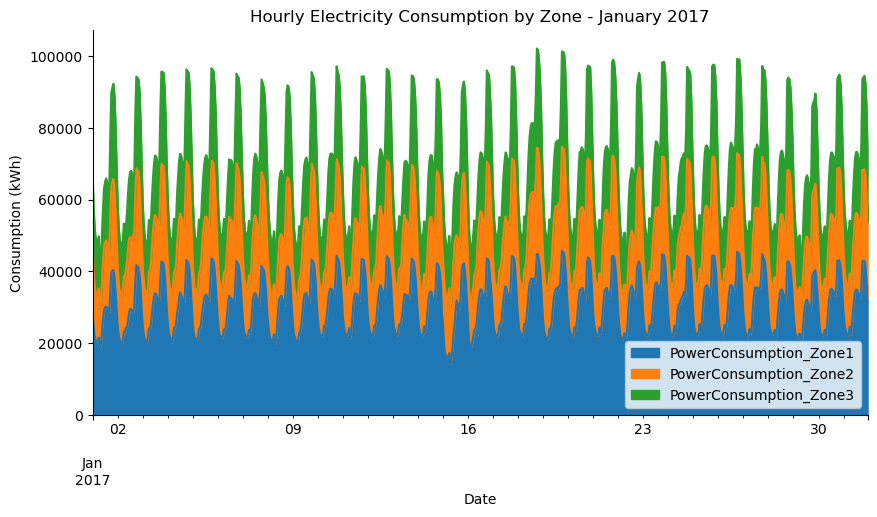

In [98]:
import seaborn as sns

(cons
.set_index("Datetime")
.resample("h")[zone_columns]
.mean()
.loc["2017-01"]
.plot
.area(
    figsize=(10,5),
     title="Hourly Electricity Consumption by Zone - January 2017",
     xlabel="Date",
     ylabel="Consumption (kWh)"
 )
)
sns.despine()

In [71]:
daily_consumption = (
    hourly["total_consumption"]
    .resample("1D")
    .mean()
)

Datetime
2017-01-01    64071.818534
2017-01-02    66247.982154
2017-01-03    68240.519974
2017-01-04    68465.603003
2017-01-05    68501.029337
Freq: D, Name: total_consumption, dtype: float64

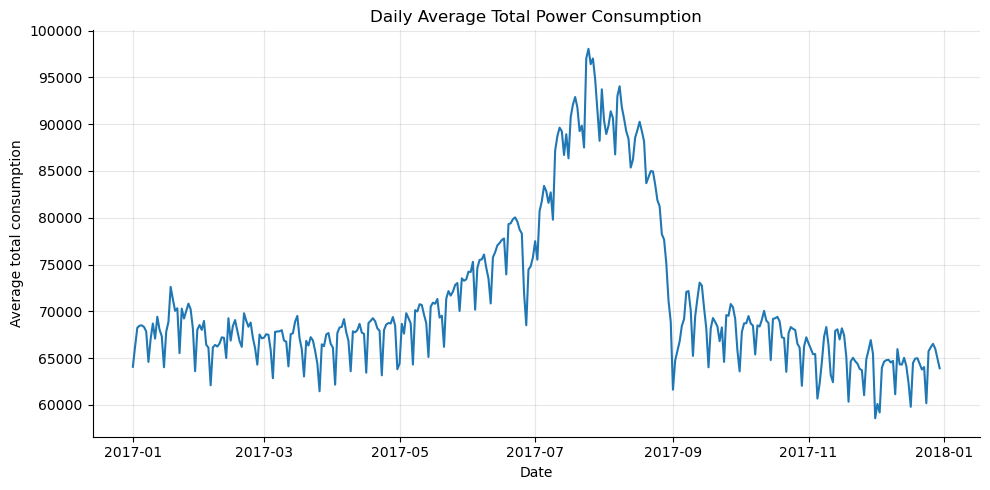

In [82]:
plt.figure(figsize=(10, 5))

plt.plot(
    daily_consumption.index,
    daily_consumption
)

plt.title("Daily Average Total Power Consumption")
plt.xlabel("Date")
plt.ylabel("Average total consumption")
plt.grid(alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()

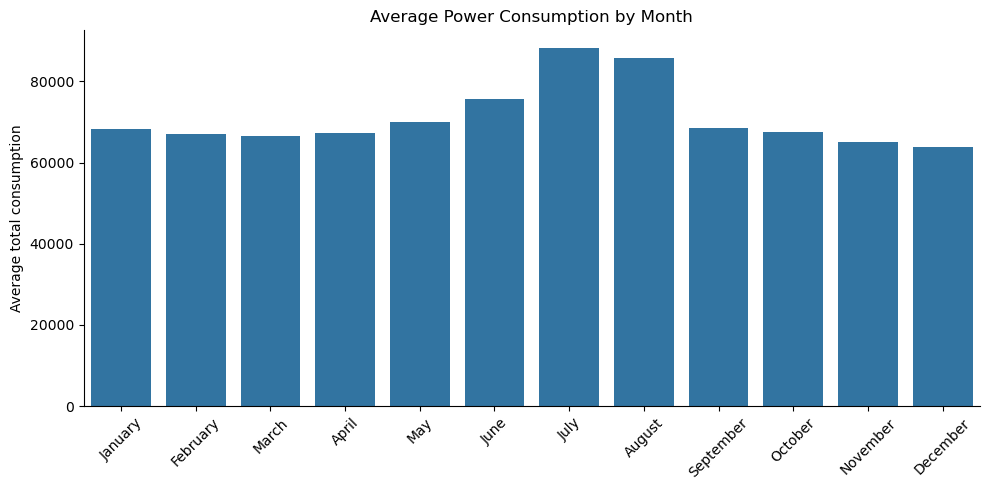

In [84]:
month_order = [ "January","February","March", "April","May","June","July","August", "September", "October", "November", "December"]

monthly_consumption = (
    hourly
    .groupby("month_name")["total_consumption"]
    .mean()
    .reindex(month_order)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=monthly_consumption.index,
    y=monthly_consumption.values
)

plt.title("Average Power Consumption by Month")
plt.xlabel("")
plt.ylabel("Average total consumption")
plt.xticks(rotation=45)

sns.despine()
plt.tight_layout()
plt.show()

In [85]:
print(
    "Month with highest consumption:",
    monthly_consumption.idxmax()
)

print(
    "Month with lowest consumption:",
    monthly_consumption.idxmin()
)

Month with highest consumption: July
Month with lowest consumption: December


In [86]:
consumption_by_hour = (
    hourly
    .groupby("hour")["total_consumption"]
    .mean()
)

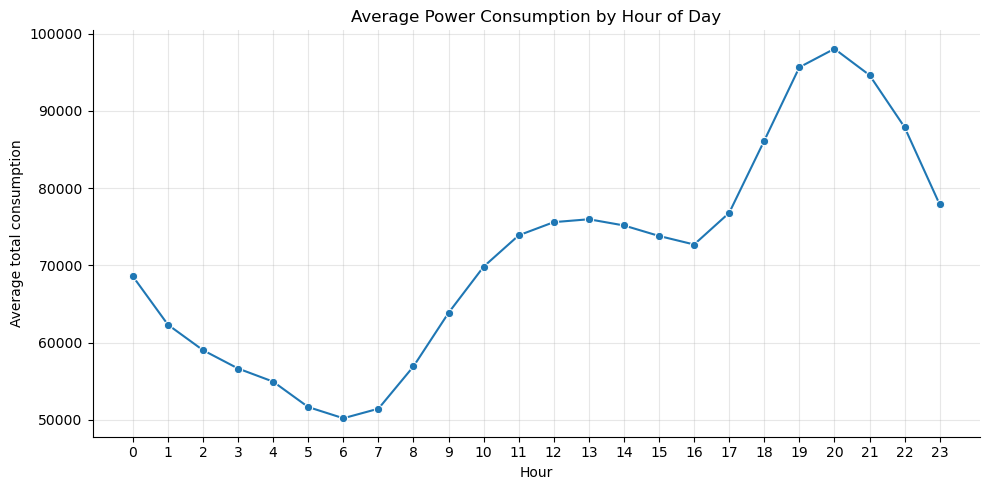

In [88]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    x=consumption_by_hour.index,
    y=consumption_by_hour.values,
    marker="o"
)

plt.title("Average Power Consumption by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average total consumption")
plt.xticks(range(24))
plt.grid(alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()

In [89]:
print(
    "Highest consumption hour:",
    consumption_by_hour.idxmax()
)

print(
    "Lowest consumption hour:",
    consumption_by_hour.idxmin()
)

Highest consumption hour: 20
Lowest consumption hour: 6


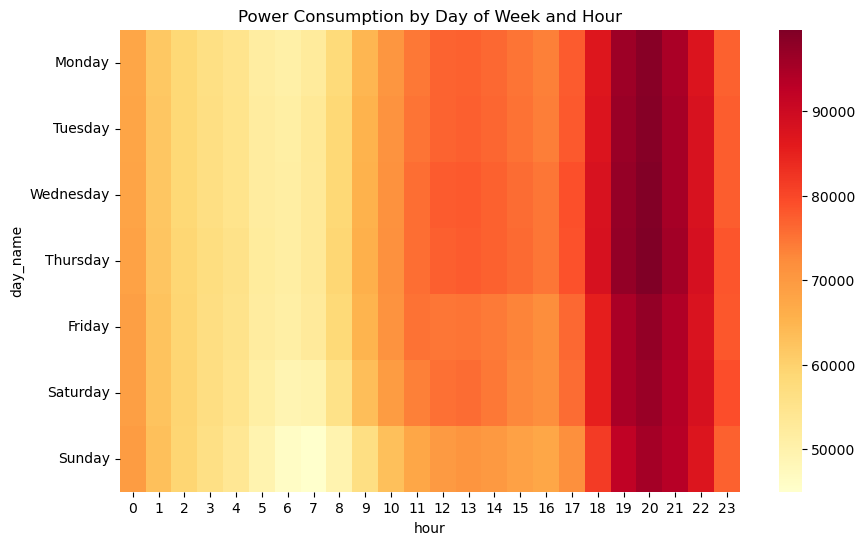

In [94]:
import matplotlib.pyplot as plt
cons_pivot = cons.pivot_table(values="total_consumption",
                              index="day_name",
                              columns="hour",
                              aggfunc="mean",
                              observed=True
                             )
plt.figure(figsize=(10, 6))

sns.heatmap(
    cons_pivot,
    cmap="YlOrRd",
    fmt=".1f"
).set(title= "Power Consumption by Day of Week and Hour")

plt.show()

In [90]:
day_type_profile = (
    hourly
    .groupby(["day_type", "hour"])["total_consumption"]
    .mean()
    .reset_index()
)

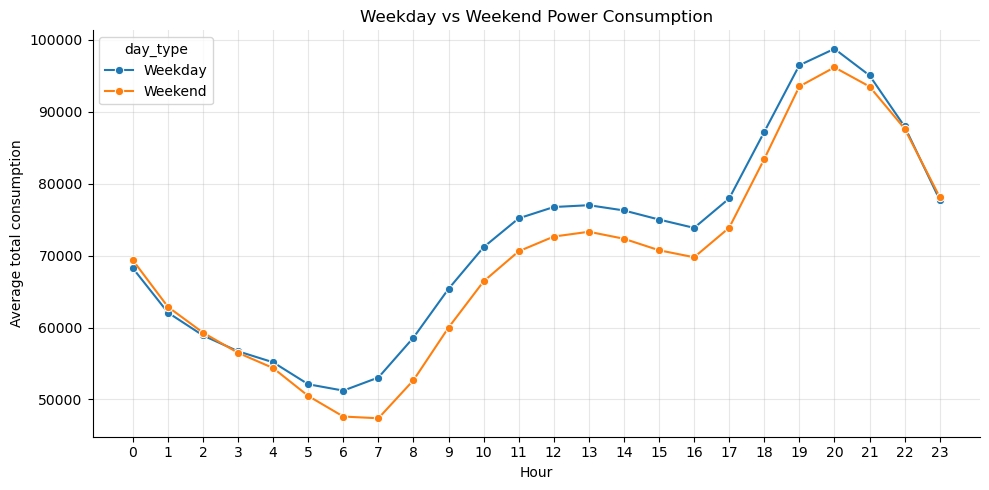

In [92]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=day_type_profile,
    x="hour",
    y="total_consumption",
    hue="day_type",
    marker="o"
)

plt.title("Weekday vs Weekend Power Consumption")
plt.xlabel("Hour")
plt.ylabel("Average total consumption")
plt.xticks(range(24))
plt.grid(alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()

In [99]:
average_by_zone = hourly[zone_columns].mean()

average_by_zone.index = [
    "Zone 1",
    "Zone 2",
    "Zone 3"
]

average_by_zone

Zone 1    32344.970564
Zone 2    21042.509082
Zone 3    17835.406218
dtype: float64

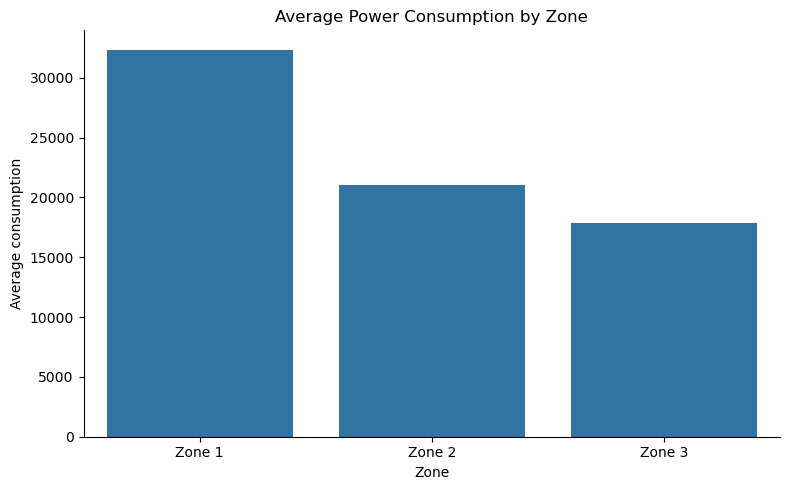

In [100]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=average_by_zone.index,
    y=average_by_zone.values
)

plt.title("Average Power Consumption by Zone")
plt.xlabel("Zone")
plt.ylabel("Average consumption")

sns.despine()
plt.tight_layout()
plt.show()

In [106]:
temperature_correlation = hourly[
    ["Temperature", "total_consumption"]
].corr()

temperature_correlation

,Temperature,total_consumption
Temperature,1.00000,0.49178
total_consumption,0.49178,1.00000


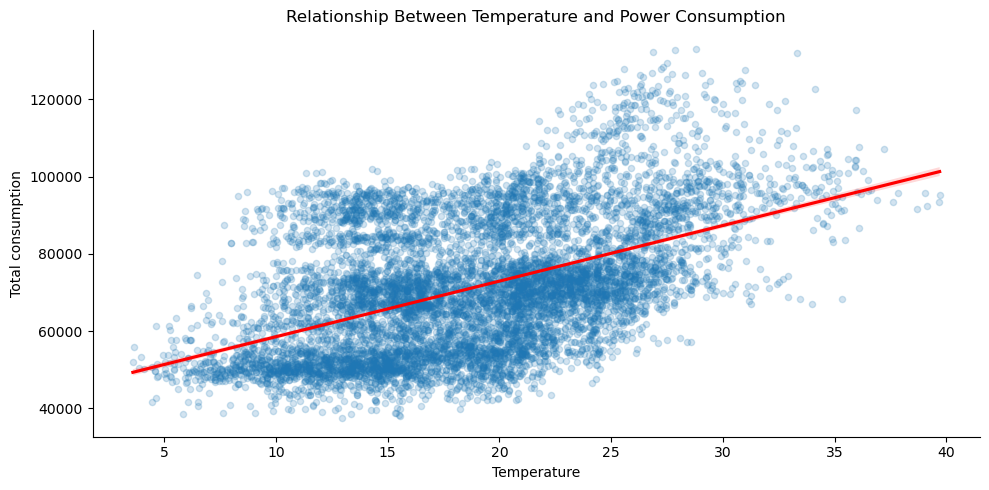

In [110]:
plt.figure(figsize=(10, 5))

sns.regplot(
    data=hourly,
    x="Temperature",
    y="total_consumption",
    scatter_kws={"alpha": 0.2, "s":20},
    line_kws={"color": "red"}
)

plt.title("Relationship Between Temperature and Power Consumption")
plt.xlabel("Temperature")
plt.ylabel("Total consumption")

sns.despine()
plt.tight_layout()
plt.show()

In [109]:
temperature_correlation = hourly[
    ["Temperature", "total_consumption"]
].corr().loc["Temperature", "total_consumption"]

print(
    "Correlation:",
    round(temperature_correlation, 2)
)

Correlation: 0.49
